In [1]:
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from datetime import timedelta
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans


import itertools

In [2]:
master_dir = "/projectnb/peaclab-mon/nishtha/datasets/final_m100_22-9/big_m100_filtered_jobs.parquet"
master_dir_df = pd.read_parquet(master_dir)

# Idea:
# Stratified Sampling (equal count sampling)
# 4 TIF bins and 7 duration bins
# Therefore, 28 categories and 20 samples for each
# Total Samples = 560

In [3]:
print(len(master_dir_df))

52098


duration_bin
30s-2min      7156
2-10min      16227
10-30min      8657
30min-1hr     6406
1-5hr         7395
5-50hr       15726
50-100hr         1
100-150hr        0
150hr+           1
Name: count, dtype: int64

In [17]:
# Total jobs = 52098
# Chose the bins such that each bin has around 6-8k jobs so we can conduct fair sampling
# Convert seconds to minutes
master_dir_df["duration_min"] = master_dir_df["duration_sec"] / 60

bins = [0.5, 3, 6.5, 17, 35, 240, 900, np.inf] 

labels = [
    "30s-3min",
    "3-6.5min",
    "6.5-17min",
    "17-35min",
    "35min-4hr",
    "4-15hr",
    "15hr+"
]

# Create bins
master_dir_df["duration_bin"] = pd.cut(
    master_dir_df["duration_min"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


counts = master_dir_df["duration_bin"].value_counts().sort_index()

print(counts)

# Cleaner table
display(
    counts.reset_index().rename(columns={
        "index": "Duration Bin",
        "duration_bin": "Job Count"
    })
)

duration_bin
30s-3min     6473
3-6.5min     8431
6.5-17min    8767
17-35min     7911
35min-4hr    7346
4-15hr       5797
15hr+        7373
Name: count, dtype: int64


,Job Count,count
0,30s-3min,6473
1,3-6.5min,8431
2,6.5-17min,8767
3,17-35min,7911
4,35min-4hr,7346
5,4-15hr,5797
6,15hr+,7373


In [18]:
print(master_dir_df.columns)

Index(['user_id', 'job_id', 'partition', 'job_state', 'start_time', 'end_time',
       'cpu_util_pct', 'gpu_util_pct', 'mem_util_pct', 'duration_sec',
       'duration_bin', 'cpu_util_pct_total', 'cpu_util_pct_valid',
       'cpu_util_pct_removed', 'mem_util_pct_total', 'mem_util_pct_valid',
       'mem_util_pct_removed', 'gpu_util_pct_total', 'gpu_util_pct_valid',
       'gpu_util_pct_removed', 'cpu_tif_cv', 'cpu_tif_trend', 'cpu_tif_mac',
       'mem_tif_cv', 'mem_tif_trend', 'mem_tif_mac', 'gpu_tif_cv',
       'gpu_tif_trend', 'gpu_tif_mac', 'cpu_tif_cv_norm', 'cpu_tif_mac_norm',
       'cpu_tif_trend_norm', 'mem_tif_cv_norm', 'mem_tif_mac_norm',
       'mem_tif_trend_norm', 'gpu_tif_cv_norm', 'gpu_tif_mac_norm',
       'gpu_tif_trend_norm', 'cpu_merged_tif', 'mem_merged_tif',
       'gpu_merged_tif', 'duration_min'],
      dtype='object')


In [20]:
# figuring out if we should use the cv tif value or the merged tif value 
bins = [0, 0.2, 0.4, 0.6, 1.0]
labels = ["<0.2", "0.2-0.4", "0.4-0.6", ">=0.6"]

# mem_tif_cv_norm
cv_counts = pd.cut(
    master_dir_df["mem_tif_cv_norm"],
    bins=bins,
    labels=labels,
    include_lowest=True
).value_counts().sort_index()

# mem_merged_tif
merged_counts = pd.cut(
    master_dir_df["mem_merged_tif"],
    bins=bins,
    labels=labels,
    include_lowest=True
).value_counts().sort_index()

print("mem_tif_cv_norm:")
print(cv_counts)

print("\nmem_merged_tif:")
print(merged_counts)

# clearly, merged tif gives better results for sampling

mem_tif_cv_norm:
mem_tif_cv_norm
<0.2       51456
0.2-0.4        5
0.4-0.6        1
>=0.6        636
Name: count, dtype: int64

mem_merged_tif:
mem_merged_tif
<0.2       51455
0.2-0.4        6
0.4-0.6      602
>=0.6         35
Name: count, dtype: int64


# Stratified Sampling Of 28 Groups

In [22]:
df = master_dir_df.copy()

# -----------------------------
# 1. Define mem_merged_tif groups
# -----------------------------
tif_bins = [0, 0.2, 0.4, 0.6, 1.0]
tif_labels = ["<0.2", "0.2-0.4", "0.4-0.6", ">=0.6"]

df["mem_tif_group"] = pd.cut(
    df["mem_merged_tif"],
    bins=tif_bins,
    labels=tif_labels,
    include_lowest=True
)

# -----------------------------
# 2. Define duration groups
# -----------------------------
df["duration_min"] = df["duration_sec"] / 60

duration_bins = [0.5, 3, 6.5, 17, 35, 240, 900, np.inf]
duration_labels = [
    "30s-3min",
    "3-6.5min",
    "6.5-17min",
    "17-35min",
    "35min-4hr",
    "4-15hr",
    "15hr+"
]

df["duration_group"] = pd.cut(
    df["duration_min"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# -----------------------------
# 3. Combine into 28 groups
# -----------------------------
df["group_column"] = (
    df["duration_group"].astype(str) + " | " + df["mem_tif_group"].astype(str)
)

# Remove rows with missing groups
df_valid = df.dropna(subset=["duration_group", "mem_tif_group"]).copy()

# -----------------------------
# 4. Stratified sampling
# -----------------------------
sampled_df = (
    df_valid
    .groupby("group_column", group_keys=False)
    .apply(lambda x: x.sample(n=min(20, len(x)), random_state=42))
    .reset_index(drop=True)
)

# -----------------------------
# 5. Print sample counts (existing groups)
# -----------------------------
sample_counts = sampled_df["group_column"].value_counts().sort_index()

print("Sample counts per group:")
print(sample_counts)

print("\nTotal samples:")
print(len(sampled_df))

# -----------------------------
# 6. Include ALL 28 groups (including 0s)
# -----------------------------
all_groups = [
    f"{d} | {t}"
    for d in duration_labels
    for t in tif_labels
]

full_sample_counts = (
    sampled_df["group_column"]
    .value_counts()
    .reindex(all_groups, fill_value=0)
)

print("\nSample counts per group (including 0s):")
print(full_sample_counts)

# Cleaner display
display(full_sample_counts.reset_index().rename(columns={
    "index": "Group",
    "group_column": "Sample Count"
}))

Sample counts per group:
group_column
15hr+ | 0.4-0.6       20
15hr+ | <0.2          20
17-35min | 0.4-0.6     1
17-35min | <0.2       20
3-6.5min | 0.2-0.4     5
3-6.5min | <0.2       20
30s-3min | 0.2-0.4     1
30s-3min | <0.2       20
35min-4hr | <0.2      20
4-15hr | 0.4-0.6      20
4-15hr | <0.2         20
4-15hr | >=0.6        20
6.5-17min | <0.2      20
Name: count, dtype: int64

Total samples:
207

Sample counts per group (including 0s):
group_column
30s-3min | <0.2        20
30s-3min | 0.2-0.4      1
30s-3min | 0.4-0.6      0
30s-3min | >=0.6        0
3-6.5min | <0.2        20
3-6.5min | 0.2-0.4      5
3-6.5min | 0.4-0.6      0
3-6.5min | >=0.6        0
6.5-17min | <0.2       20
6.5-17min | 0.2-0.4     0
6.5-17min | 0.4-0.6     0
6.5-17min | >=0.6       0
17-35min | <0.2        20
17-35min | 0.2-0.4      0
17-35min | 0.4-0.6      1
17-35min | >=0.6        0
35min-4hr | <0.2       20
35min-4hr | 0.2-0.4     0
35min-4hr | 0.4-0.6     0
35min-4hr | >=0.6       0
4-15hr | <0.2    

,Sample Count,count
0,30s-3min | <0.2,20
1,30s-3min | 0.2-0.4,1
2,30s-3min | 0.4-0.6,0
3,30s-3min | >=0.6,0
4,3-6.5min | <0.2,20
5,3-6.5min | 0.2-0.4,5
6,3-6.5min | 0.4-0.6,0
7,3-6.5min | >=0.6,0
8,6.5-17min | <0.2,20
9,6.5-17min | 0.2-0.4,0


In [24]:
# Working with 207 samples
sampled_df.head()

,user_id,job_id,partition,job_state,start_time,end_time,cpu_util_pct,gpu_util_pct,mem_util_pct,duration_sec,...,gpu_tif_cv_norm,gpu_tif_mac_norm,gpu_tif_trend_norm,cpu_merged_tif,mem_merged_tif,gpu_merged_tif,duration_min,mem_tif_group,duration_group,group_column
0,1532,3889988,1,COMPLETED,2022-09-20 17:48:01+00:00,2022-09-21 16:34:20+00:00,"[57.25723140495868, 57.48597992916175, 57.5154...","[97.93388429752066, 98.14049586776859, 98.1995...","[67.61973878394333, 67.83668093270366, 67.9289...",81979.0,...,0.587961,0.227347,0.000284,0.480012,0.484991,0.326180,1366.316667,0.4-0.6,15hr+,15hr+ | 0.4-0.6
1,1234,292273,1,COMPLETED,2022-09-20 14:44:42+00:00,2022-09-21 12:40:48+00:00,"[59.260760613207545, 59.260760613207545, 59.26...","[95.93160377358491, 95.93160377358491, 95.9316...","[67.2710568985849, 67.2710568985849, 67.271056...",78966.0,...,0.583519,0.236503,0.000869,0.493799,0.494462,0.328183,1316.100000,0.4-0.6,15hr+,15hr+ | 0.4-0.6
2,1529,4679097,1,COMPLETED,2022-09-20 14:42:28+00:00,2022-09-21 10:21:54+00:00,"[59.260760613207545, 59.260760613207545, 59.26...","[95.93160377358491, 95.93160377358491, 95.9316...","[67.2710568985849, 67.2710568985849, 67.271056...",70766.0,...,0.571191,0.264699,0.001477,0.505459,0.502376,0.334652,1179.433333,0.4-0.6,15hr+,15hr+ | 0.4-0.6
3,1540,2459402,1,COMPLETED,2022-09-20 14:42:29+00:00,2022-09-21 11:22:56+00:00,"[59.260760613207545, 59.260760613207545, 59.26...","[95.93160377358491, 95.93160377358491, 95.9316...","[67.2710568985849, 67.2710568985849, 67.271056...",74427.0,...,0.576944,0.251528,0.001170,0.500523,0.499040,0.331623,1240.450000,0.4-0.6,15hr+,15hr+ | 0.4-0.6
4,1498,4894609,1,COMPLETED,2022-09-20 14:48:35+00:00,2022-09-21 14:34:15+00:00,"[59.806161556603776, 59.806161556603776, 59.86...","[96.40330188679245, 96.40330188679245, 96.4622...","[67.8212485259434, 67.8212485259434, 67.934456...",85540.0,...,0.592063,0.217745,0.000558,0.481692,0.486230,0.324035,1425.666667,0.4-0.6,15hr+,15hr+ | 0.4-0.6


# Total Samples = 207

# PELT Method For Each Job In Sample

In [25]:
import ruptures as rpt

def pelt_mem_phases(mem_values, model="rbf", pen=12, step_seconds=10):
    
    """
    Returns:
      num_phases
      phase_values_nested:
          [[phase1 util values], [phase2 util values], ...]
      phase_summary_nested:
          [[phase1 max value, phase1 duration seconds],
           [phase2 max value, phase2 duration seconds], ...]
    """

    if mem_values is None:
        return 0, [], []

    values = np.array(mem_values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return 0, [], []

    # Prepare for PELT (always)
    signal = values.reshape(-1, 1)

    algo = rpt.Pelt(model=model).fit(signal)
    change_points = algo.predict(pen=pen)

    start = 0
    phase_values = []
    phase_summary = []

    for end in change_points:
        phase = values[start:end]

        if len(phase) > 0:
            phase_list = phase.tolist()
            phase_values.append(phase_list)

            phase_max = float(np.max(phase))
            phase_duration = len(phase) * step_seconds

            phase_summary.append([phase_max, phase_duration])

        start = end

    return len(phase_values), phase_values, phase_summary

In [26]:
results = sampled_df["mem_util_pct"].apply(
    lambda x: pelt_mem_phases(
        x,
        model="rbf",
        pen=12,
        step_seconds=10
    )
)

sampled_df["mem_pelt_num_phases"] = results.apply(lambda x: x[0])
sampled_df["mem_pelt_phase_values"] = results.apply(lambda x: x[1])
sampled_df["mem_pelt_phase_summary"] = results.apply(lambda x: x[2])

In [28]:
# Applied PELT Method for each of the 207 jobs in the stratified sample
sampled_df[[
    "job_id",
    "group_column",
    "mem_pelt_num_phases", # number of phases/segments detected
    "mem_pelt_phase_values", # nested list of util values in each phase
    "mem_pelt_phase_summary" # max value and duration for each phase
]].head()

,job_id,group_column,mem_pelt_num_phases,mem_pelt_phase_values,mem_pelt_phase_summary
0,3889988,15hr+ | 0.4-0.6,41,"[[67.61973878394333, 67.83668093270366, 67.928...","[[67.92891824085005, 650], [67.77159828807557,..."
1,292273,15hr+ | 0.4-0.6,64,"[[67.2710568985849, 67.2710568985849, 67.27105...","[[68.00634581367925, 1150], [68.63665241745284..."
2,4679097,15hr+ | 0.4-0.6,59,"[[67.2710568985849, 67.2710568985849, 67.27105...","[[68.00634581367925, 1150], [68.63665241745284..."
3,2459402,15hr+ | 0.4-0.6,62,"[[67.2710568985849, 67.2710568985849, 67.27105...","[[68.00634581367925, 1150], [68.63665241745284..."
4,4894609,15hr+ | 0.4-0.6,62,"[[67.8212485259434, 67.8212485259434, 67.93445...","[[68.00634581367925, 1100], [68.63665241745284..."


# Heatmap - Relation Between The Number Of Phases Using PELT and TIF-Duration Groups

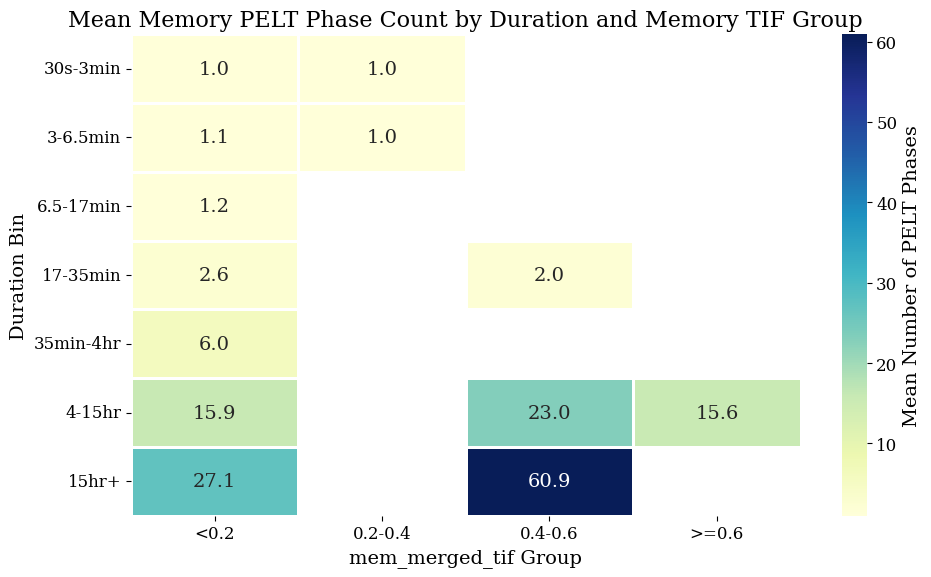

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Pivot table: y = duration, x = mem TIF group, values = mean phases
heatmap_data = sampled_df.pivot_table(
    index="duration_group",
    columns="mem_tif_group",
    values="mem_pelt_num_phases",
    aggfunc="mean"
)

# Force correct order
heatmap_data = heatmap_data.reindex(
    index=duration_labels,
    columns=tif_labels
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Mean Number of PELT Phases"}
)

plt.title("Mean Memory PELT Phase Count by Duration and Memory TIF Group")
plt.xlabel("mem_merged_tif Group")
plt.ylabel("Duration Bin")
plt.tight_layout()
plt.show()

# Heatmap - Using PELT, The Number of Phases In Each Max Utilization Value and Duration Bin

# Choosing 1 Random Job Per TIF-Duration Group

In [32]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# -----------------------------
# Pick one random job per group_column
# -----------------------------
random_jobs = (
    sampled_df
    .groupby("group_column", group_keys=False)
    .sample(n=1, random_state=42)
    .reset_index(drop=True)
)

print("Number of random jobs selected:", len(random_jobs))
display(random_jobs[["job_id", "group_column", "mem_pelt_num_phases"]])

Number of random jobs selected: 13


,job_id,group_column,mem_pelt_num_phases
0,3889988,15hr+ | 0.4-0.6,41
1,2183412,15hr+ | <0.2,42
2,354777,17-35min | 0.4-0.6,2
3,3962509,17-35min | <0.2,1
4,2427955,3-6.5min | 0.2-0.4,1
5,1577874,3-6.5min | <0.2,1
6,2809575,30s-3min | 0.2-0.4,1
7,5713000,30s-3min | <0.2,1
8,1924232,35min-4hr | <0.2,8
9,3897839,4-15hr | 0.4-0.6,30


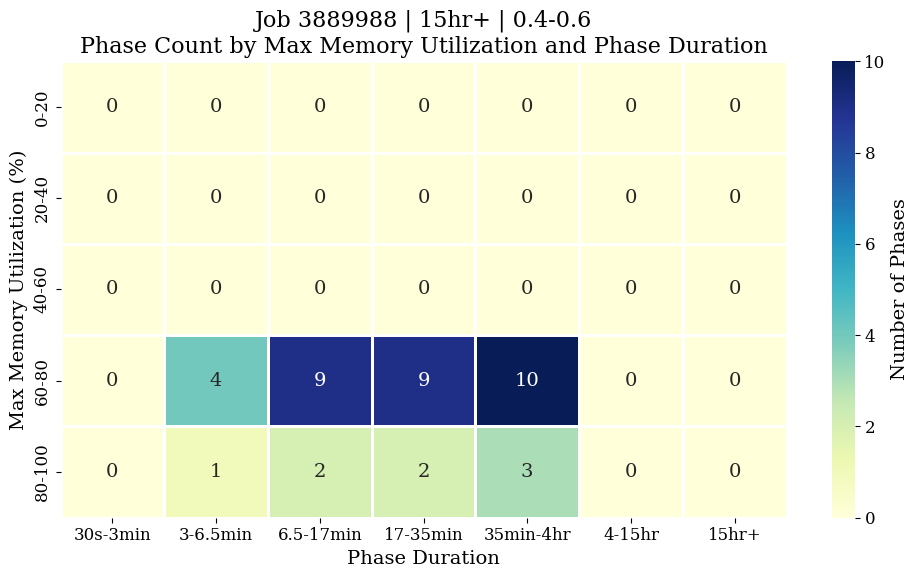

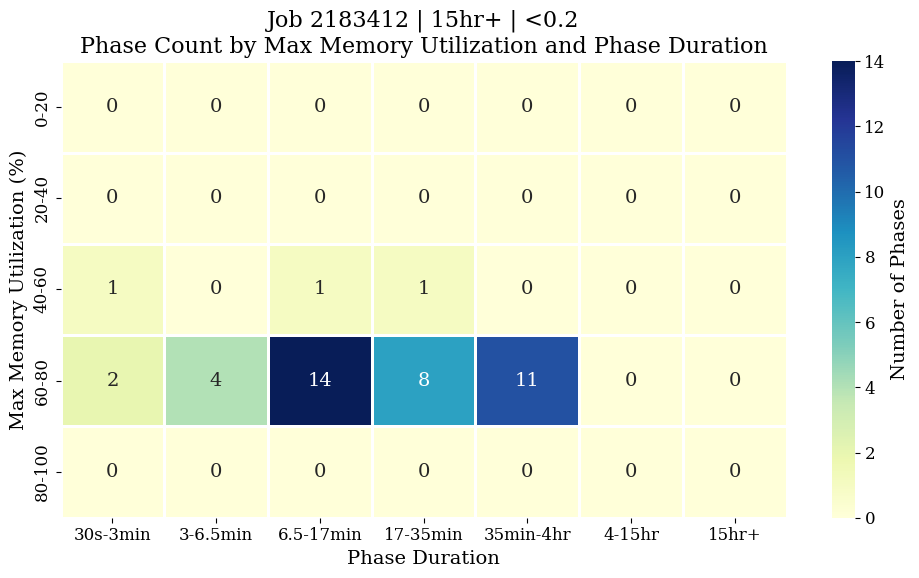

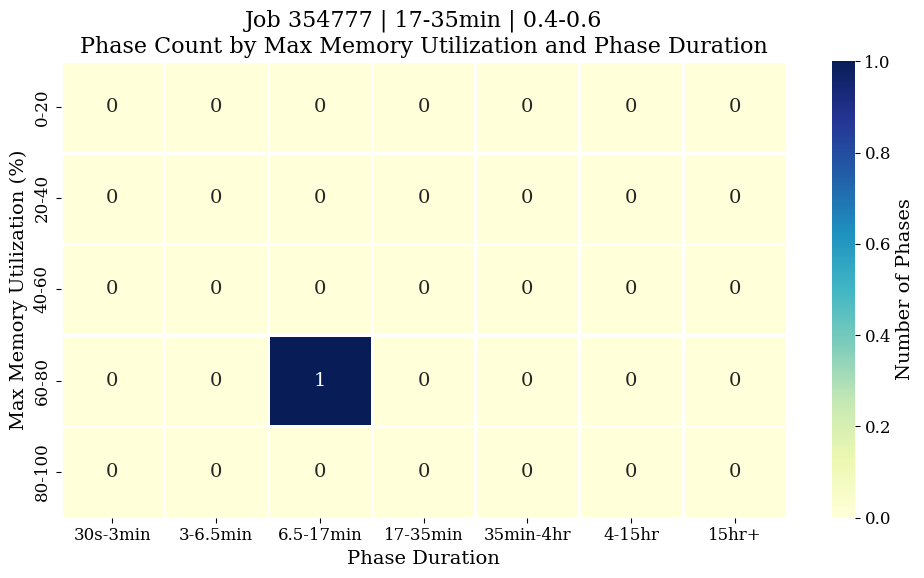

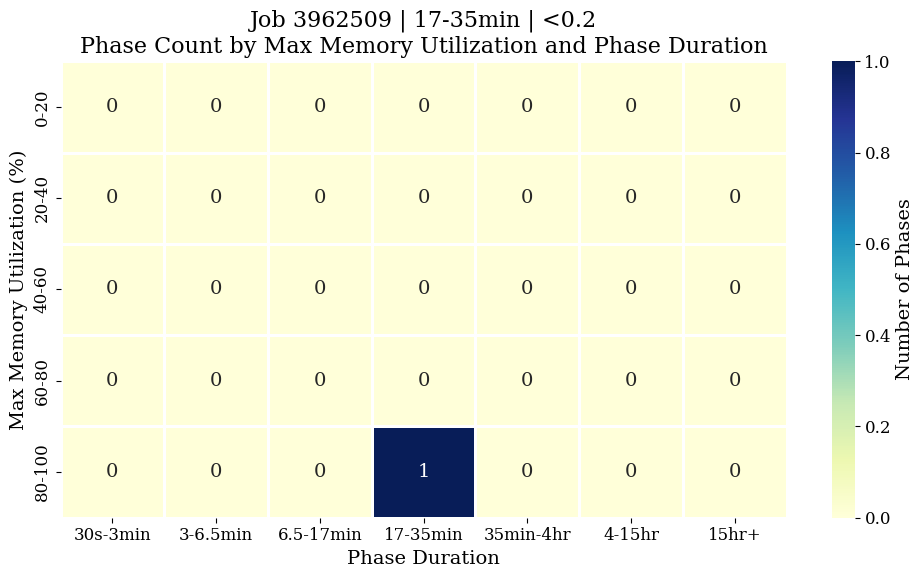

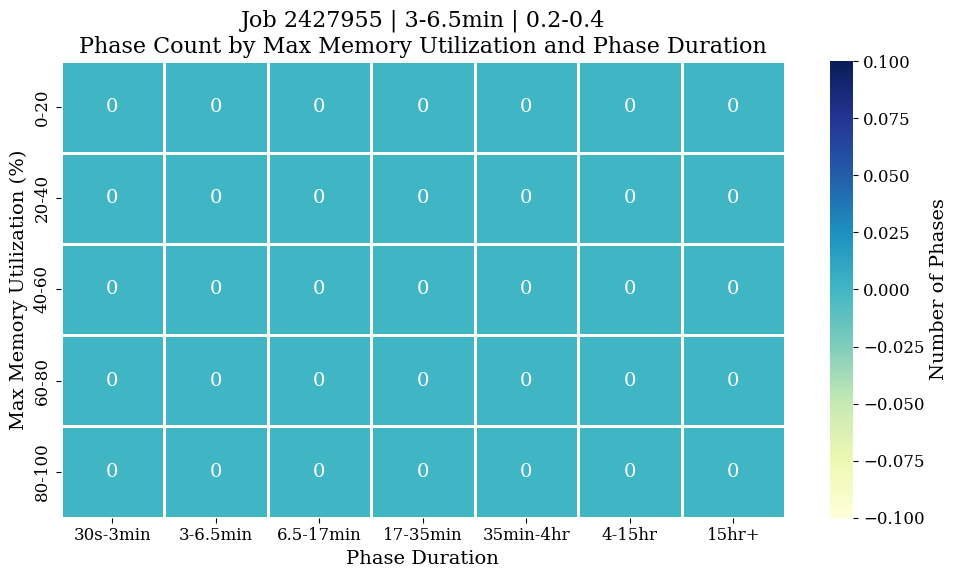

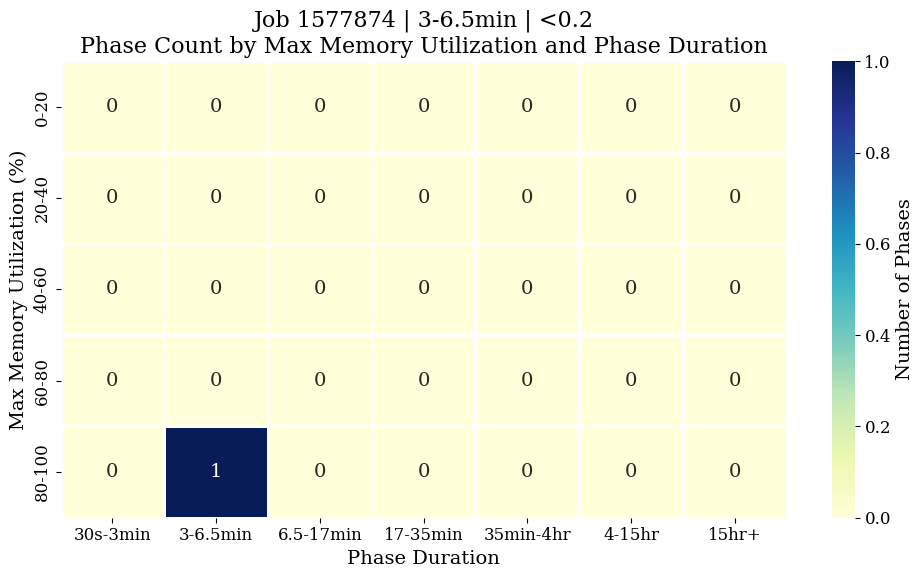

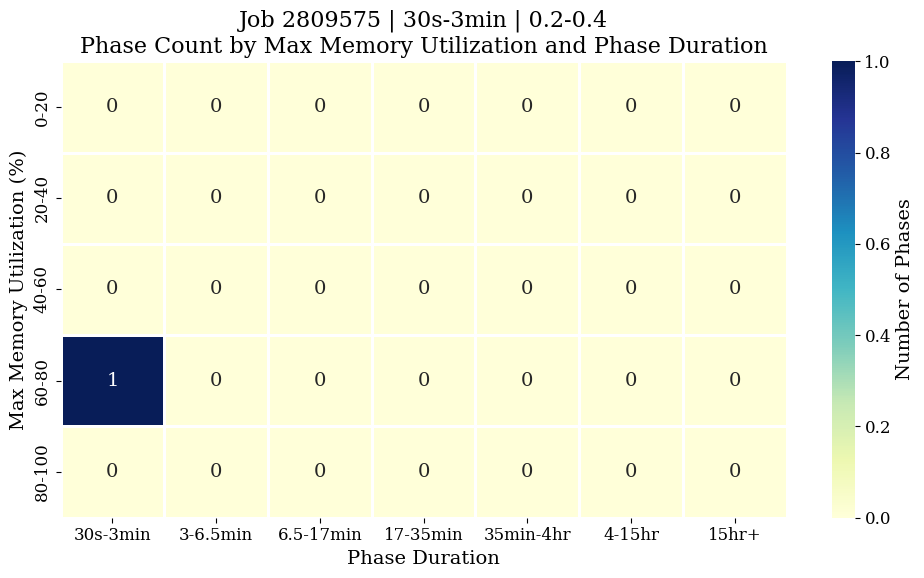

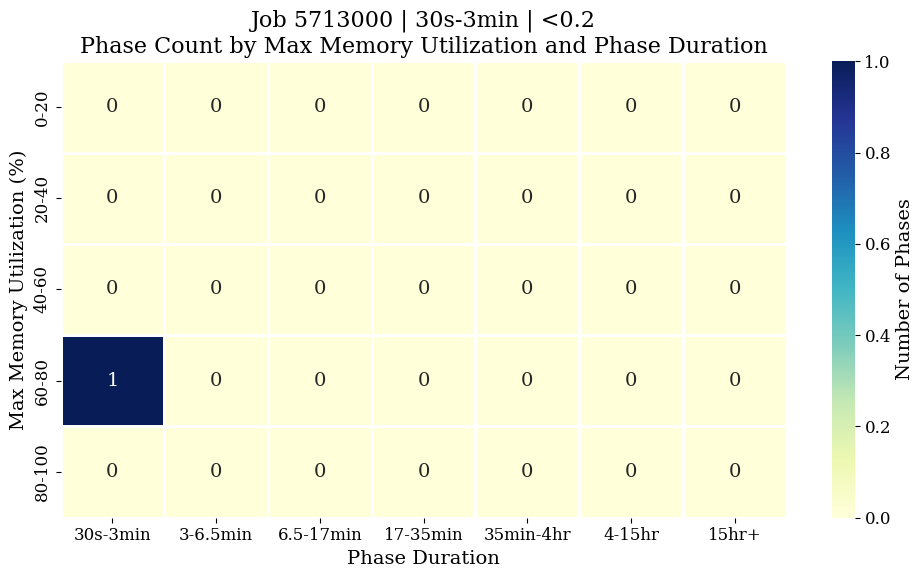

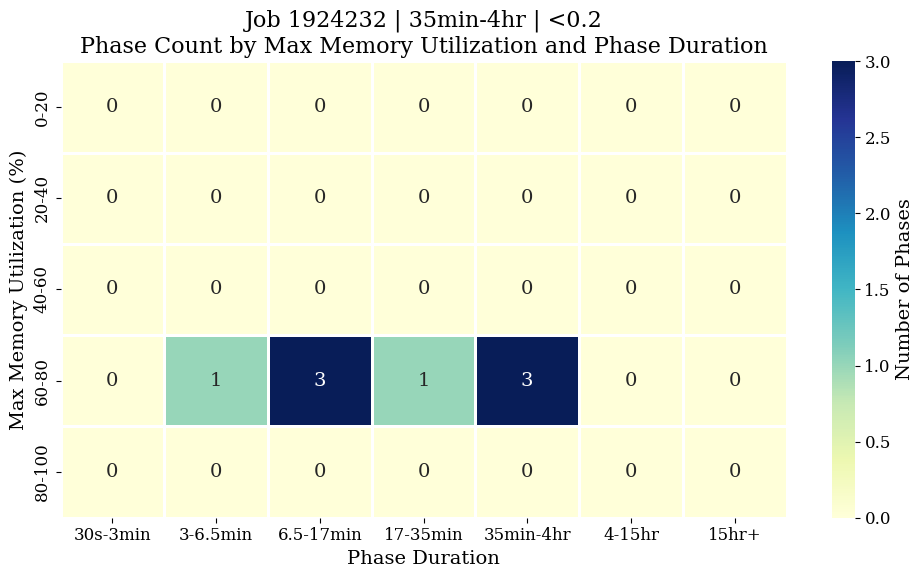

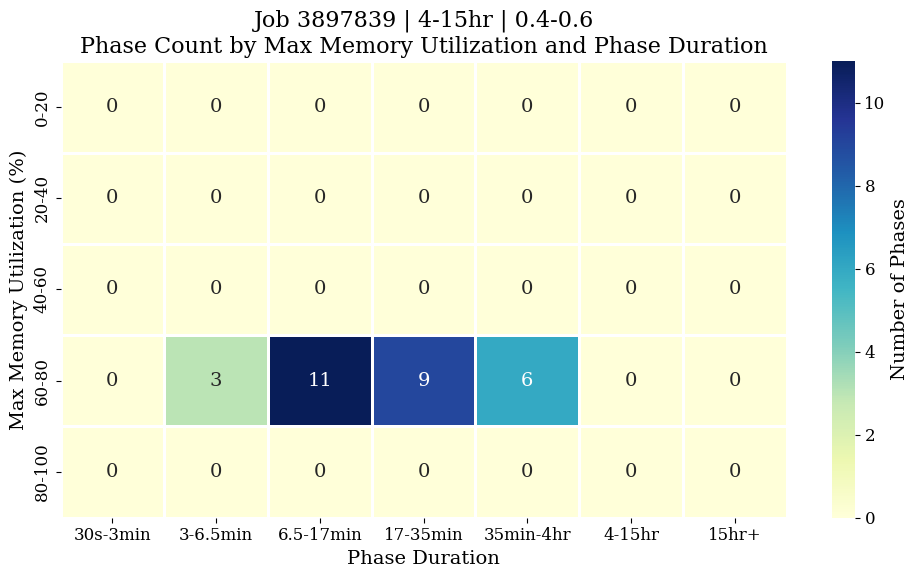

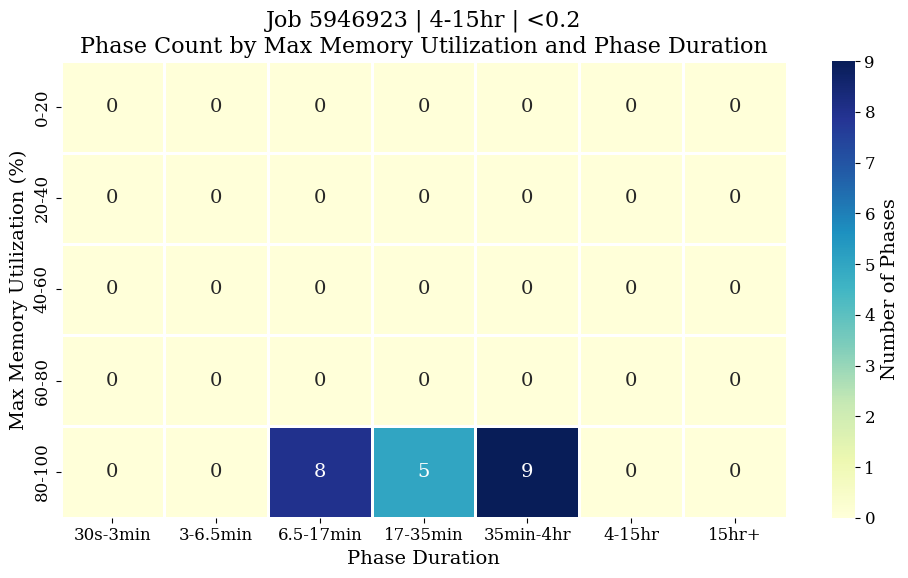

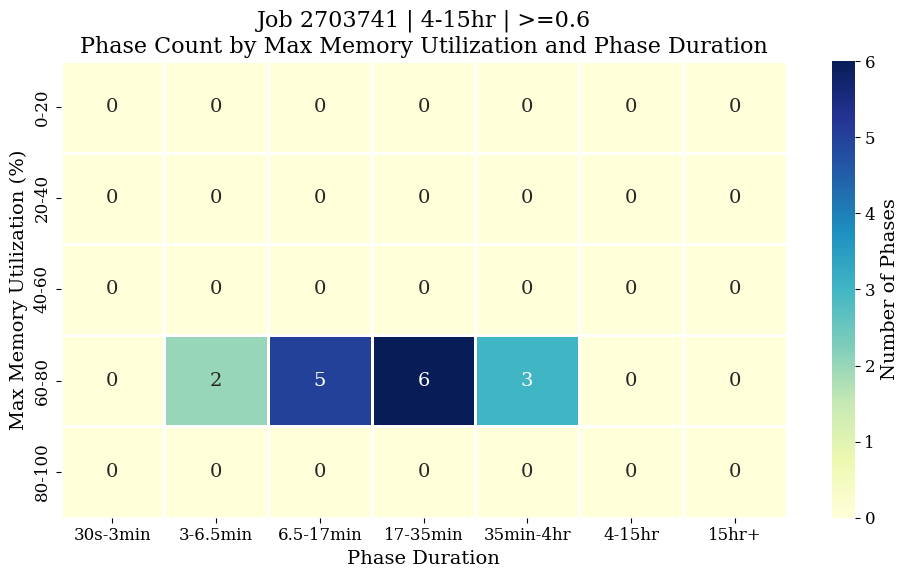

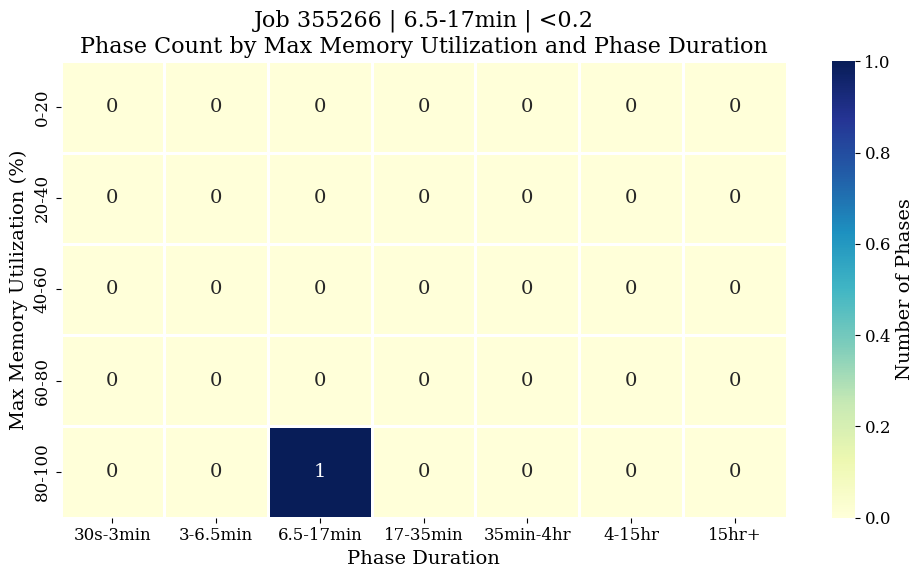

In [36]:
# -----------------------------
# Function to plot phase heatmap for one job
# -----------------------------
def plot_phase_summary_heatmap(row):
    job_id = row["job_id"]
    group = row["group_column"]
    phase_summary = row["mem_pelt_phase_summary"]

    # phase_summary = [[max_mem_util, duration_sec], ...]
    phase_df = pd.DataFrame(
        phase_summary,
        columns=["max_mem_util_pct", "phase_duration_sec"]
    )

    # Convert duration to minutes for readability
    phase_df["phase_duration_min"] = phase_df["phase_duration_sec"] / 60

    # Bin max memory utilization
    mem_bins = [0, 20, 40, 60, 80, 100]
    mem_labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]

    # Bin phase duration
    duration_bins = [0.5, 3, 6.5, 17, 35, 240, 900, np.inf]
    duration_labels = [
        "30s-3min",
        "3-6.5min",
        "6.5-17min",
        "17-35min",
        "35min-4hr",
        "4-15hr",
        "15hr+"
    ]

    phase_df["max_mem_bin"] = pd.cut(
        phase_df["max_mem_util_pct"],
        bins=mem_bins,
        labels=mem_labels,
        include_lowest=True
    )

    phase_df["duration_bin"] = pd.cut(
        phase_df["phase_duration_min"],
        bins=duration_bins,
        labels=duration_labels,
        include_lowest=True
    )

    heatmap_data = (
        phase_df
        .groupby(["max_mem_bin", "duration_bin"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=mem_labels, columns=duration_labels, fill_value=0)
    )

    plt.figure(figsize=(10, 6))

    #sns.heatmap(heatmap_data,annot=True,fmt="d",cmap="mako",linewidths=0.7,linecolor="white",cbar_kws={"label": "Number of Phases"})
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlGnBu",   # yellow → green → blue
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Number of Phases"}
    )


    plt.title(f"Job {job_id} | {group}\nPhase Count by Max Memory Utilization and Phase Duration")
    plt.xlabel("Phase Duration")
    plt.ylabel("Max Memory Utilization (%)")
    plt.tight_layout()
    plt.show()
    
# -----------------------------
# Plot one heatmap for each unique group_column
# -----------------------------
for _, row in random_jobs.iterrows():
    plot_phase_summary_heatmap(row)

# Plotting Same Heatmap For Entire sample_df

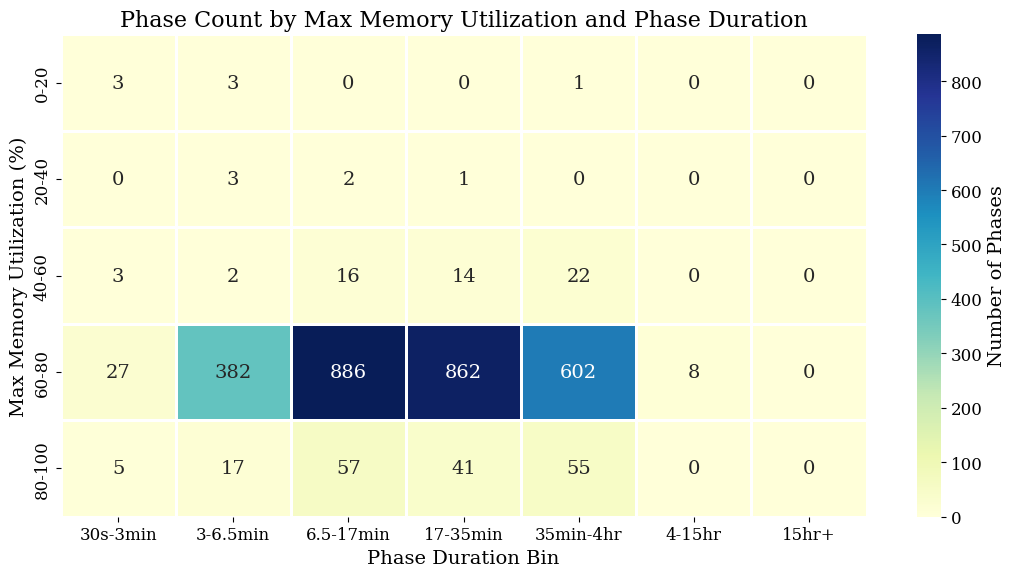

In [35]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# -----------------------------
# Expand mem_pelt_phase_summary for entire sampled_df
# -----------------------------
phase_rows = []

for _, row in sampled_df.iterrows():
    for phase in row["mem_pelt_phase_summary"]:
        phase_rows.append({
            "job_id": row["job_id"],
            "group_column": row["group_column"],
            "max_mem_util_pct": phase[0],
            "phase_duration_sec": phase[1]
        })

phase_df = pd.DataFrame(phase_rows)

# Convert duration seconds to minutes
phase_df["phase_duration_min"] = phase_df["phase_duration_sec"] / 60

# -----------------------------
# Use same bins
# -----------------------------
mem_bins = [0, 20, 40, 60, 80, 100]
mem_labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]

duration_bins = [0.5, 3, 6.5, 17, 35, 240, 900, np.inf]
duration_labels = [
    "30s-3min",
    "3-6.5min",
    "6.5-17min",
    "17-35min",
    "35min-4hr",
    "4-15hr",
    "15hr+"
]

phase_df["max_mem_bin"] = pd.cut(
    phase_df["max_mem_util_pct"],
    bins=mem_bins,
    labels=mem_labels,
    include_lowest=True
)

phase_df["phase_duration_bin"] = pd.cut(
    phase_df["phase_duration_min"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# -----------------------------
# Heatmap data: count phases per combination
# -----------------------------
heatmap_data = (
    phase_df
    .groupby(["max_mem_bin", "phase_duration_bin"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=mem_labels, columns=duration_labels, fill_value=0)
)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlGnBu",   # yellow → green → blue
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Number of Phases"}
)

plt.title("Phase Count by Max Memory Utilization and Phase Duration")
plt.xlabel("Phase Duration Bin")
plt.ylabel("Max Memory Utilization (%)")
plt.tight_layout()
plt.show()